# Experiment 0 — Prompt baseline

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

def read_results(experiment):
    files = sorted((ROOT / "results" / experiment).glob("*.json"))
    return [json.loads(path.read_text()) for path in files]

rows = read_results("00_prompt_baseline")
summary = pd.DataFrame({
    "prompt": [row["prompt"] for row in rows],
    "accuracy": [row["accuracy"] for row in rows],
    "format_rate": [row["format_rate"] for row in rows],
    "mean_tokens": [row["mean_response_length"] for row in rows],
}).set_index("prompt")
summary.style.format({"accuracy": "{:.2%}", "format_rate": "{:.2%}", "mean_tokens": "{:.1f}"})

,accuracy,format_rate,mean_tokens
prompt,,,
question_only,20.24%,67.02%,330.4
r1_zero,0.53%,32.83%,162.5
r1_zero_three_shot,15.77%,84.31%,168.1


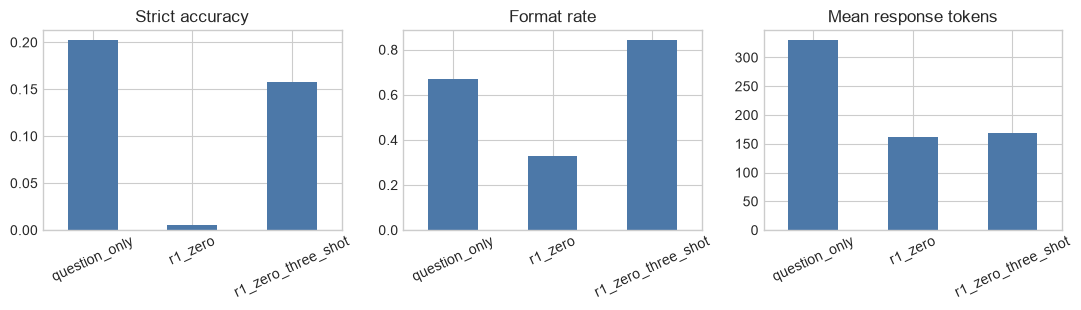

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axis, column, title in zip(axes, summary.columns, ["Strict accuracy", "Format rate", "Mean response tokens"]):
    summary[column].plot.bar(ax=axis, color="#4C78A8")
    axis.set_title(title); axis.set_xlabel(""); axis.tick_params(axis="x", rotation=25)
fig.tight_layout()
# fig.savefig(FIGURES / "00_prompt_baseline.png", dpi=180, bbox_inches="tight")